# Title: Evaluating LLMs on Stable Matching and Preference Reasoning Tasks

#### Name: Dana Aljamal, Nimrah Adam, Shahida Batool
#### Course: DS8008 - NLP (Text Mining) - W2026
#### Date: April 15, 2026

-----------------------------------------

## 1. Introduction


Large Language Models (LLMs) have shown strong performance on many reasoning tasks, but their ability to perform structured, multi-step algorithmic reasoning remains limited. This is especially evident in problems involving ranked preferences and combinatorial decision-making.

The stable matching problem provides a useful testbed for this. It requires matching two groups based on preferences while ensuring stability, typically solved using the Deferred Acceptance algorithm. While LLMs can often interpret preferences, they may struggle to execute the full sequence of steps required to produce stable solutions, particularly as problem size increases .

In this project, we evaluate LLM performance across four tasks: stable matching generation, instability detection, instability resolution, and preference reasoning. We compare models of varying capability, including a basic model, a larger reasoning model, and an advanced model (Gemini), to analyze how performance changes with task complexity.

Our goal is to understand the extent to which LLMs can handle structured reasoning beyond simple pattern recognition.

## 2. Background

The Stable Matching Problem is a classical problem in algorithm design and game theory, with applications in markets such as college admissions, job allocation, and resource matching. Given two groups of agents with ranked preferences over one another, the goal is to find a matching with no blocking pairs. A blocking pair is a pair of agents who prefer each other over their assigned partners, making the matching unstable.

A key property of this problem is that stable solutions can be found using the Deferred Acceptance (Gale–Shapley) algorithm, which guarantees a stable matching through an iterative process of proposals and rejections. This requires maintaining consistency across multiple steps, where each decision affects future outcomes.

From a reasoning perspective, the problem combines local preference comparisons with global constraints. While checking a single preference is simple, ensuring overall stability requires evaluating all possible pairs and maintaining a consistent matching structure.

This makes stable matching a useful benchmark for evaluating whether large language models (LLMs) can perform multi-step, structured reasoning, rather than relying on pattern recognition or isolated decisions.

## 2.1 Paper Connection and Comparison

This project replicates the core experimental framework from:
> **"Matching Markets Meet LLMs: Algorithmic Reasoning with Ranked Preferences"** — Hosseini et al. (2025). [[Link to Paper]](https://arxiv.org/pdf/2506.04478)

### Paper Summary

Hosseini et al. (2025) evaluate **seven state-of-the-art LLMs** — including GPT-4, Llama variants, and Mistral — across four structured reasoning tasks derived from the Stable Matching problem. Their key findings are:

- Models consistently achieve **high validity** (well-formed outputs) but **fail to enforce global stability**, particularly as market sizes grow.
- **Preference reasoning** (Task 4) is substantially easier for models than **stable matching generation** (Task 1), revealing that local reasoning is within LLM reach but global algorithmic execution is not.
- Applying **LoRA fine-tuning** improves performance on small markets but does not resolve degradation at scale.
- **Blocking pair analysis** reveals that models fail iteratively — they cannot maintain consistency across all agent pairs simultaneously, which is the defining challenge of the Deferred Acceptance algorithm.

This project replicates their core tasks and findings at a smaller scale, using the Groq API and Gemini for a practical multi-model comparison within the course scope.


### Architecture & Experimental Framework

The diagram below shows the paper's experimental architecture, which we use as the backbone for our evaluation pipeline:

![Architecture Framework](architecture.png)
*Architecture Diagram — Hosseini et al. (2025)*


### Detailed Comparison: Hosseini et al. (2025) vs. Our Project

| Aspect | Hosseini et al. (2025) | Our Project |
| :--- | :--- | :--- |
| **Core Problem** | Evaluate LLMs on stable matching and preference reasoning | Same |
| **Tasks Covered** | Generate stable matching, detect instability, resolve instability, preference queries | Same four tasks |
| **Metrics Used** | Validity, stability, exact match, blocking pairs, accuracy | Same metrics |
| **Key Finding** | Models achieve high validity but struggle with stability; preference reasoning easier than generation | Confirmed: ~30% stable matching accuracy, ~70% preference reasoning accuracy |
| **Scalability Analysis** | Tests on small, medium, and large markets; performance degrades at scale | Limited scalability testing across small, medium, and large market sizes using Gemini; similar degradation trends observed |
| **Models Evaluated** | 7 state-of-the-art LLMs | 3 models: llama-3.1-8b (basic), llama-3.3-70b (larger), Gemini 2.5 Pro (advanced) |
| **Fine-Tuning (LoRA)** | Applies LoRA; improves small markets but not large ones | No fine-tuning — pure zero-shot inference only |
| **Dataset Scale** | Uses both Impartial Culture (IC) and Master List distributions | Subset of synthetic IC datasets(Easy); evaluated on 10–20 instances using the basic and large models(Task1-Task4) |
| **Dataset Type** | Large-scale experiments across multiple market sizes and datasets (IC and Master List) | Uses only IC datasets to ensure unbiased and fully random preference structures |
| **Blocking Pair Analysis** | Detailed analysis of iterative failure patterns using blocking pairs | Blocking pairs tracked as a metric; no detailed failure analysis performed |
| **Prompt Engineering** | Systematic prompt design and ablation across multiple prompt variants |Task-specific structured prompts adapted from paper’s GitHub; no prompt ablation|
| **Advanced Model Usage** | Multiple advanced models evaluated across all tasks | Gemini 2.5 Pro used selectively for Task 1 (stable matching generation) due to computational cost |


> **Project Scope Note:** This project replicates the core tasks and findings of the paper at a smaller scale. Key differences include fewer models evaluated, no LoRA fine-tuning, 
and a reduced dataset and prompt analysis.
Due to computational constraints, we used a subset of accessible models (via Groq API and Gemini) rather than the full set evaluated in the paper, while still aiming to validate its main insights.

## 3. Methodology

This section describes the experimental framework used to evaluate LLM performance on stable matching tasks. We define the dataset and task structure, outline the models used for comparison, and describe the procedure followed to generate and evaluate results.

The methodology is divided into three components: dataset and task design, model setup, and experimental procedure.

### 3.1 Model Setup and API Access

We evaluate three models with different levels of capability to trace how architectural scaling impacts algorithmic reasoning.

- **Basic Model (`llama-3.1-8b-instant`)**: Accessed via the **Groq API** for ultra-fast, low-latency zero-shot responses. Provides a baseline for basic instruction following.
- **Reasoning Model (`llama-3.3-70b-versatile`)**: Also accessed via the **Groq API**. A significantly larger model parameterized for deeper context understanding.
- **Advanced Scaling Model (`Gemini`)**: Used specifically to evaluate how performance collapses on large-scale datasets (N=50 agents), highlighting foundational algorithmic limitations across SOTA endpoints.

**How it works**: The notebook uses the `ChatGroq` package to interact securely with these LLMs. All raw reasoning traces are streamed directly into JSON output formats for automated verification.


### 3.2 Dataset and Pipeline Design

To rigorously test matching limits, we use synthetically generated instances from the **Impartial Culture (IC)** setting, where agents hold uniform, randomly assigned preference distributions.

**Datasets used in this notebook:**
- **`5_ic_processed.csv`**: The primary dataset. Represents a market of 5 Proposers and 5 Acceptors. Used for all four tasks in both the Basic and Reasoning model evaluations.

> **Note:** Both 20-agent and 50-agent dataset were used externally for the Gemini scaling analysis (see `gemini_stable_matching_evaluation.ipynb`) but the 50-agent dataset is not included in this repository.

**The Four Tasks:**
1. **Task 1: Stable Matching Generation** — Given preference lists, generate a complete stable matching.
2. **Task 2: Instability Detection** — Given a matching, determine YES/NO whether it is stable.
3. **Task 3: Instability Resolution** — Given an unstable matching, repair it into a stable one.
4. **Task 4: Preference Reasoning** — Answer a preference-based query from ranked preference lists.

**Why only the 5-agent IC dataset was used for Tasks 1–4:**  
The Groq-based models showed limited stable matching performance even on the smallest 5-agent IC instances. As a result, extending all tasks to harder datasets was unlikely to provide meaningful insights, so experiments were restricted to 5_ic_processed.csv

### 3.3 Experimental Procedure

The experiments are conducted task by task. For each task, the models are provided with structured inputs containing preference lists or matchings, and are required to produce outputs in a predefined JSON format.

For Tasks 1–4, both the basic and reasoning models are evaluated on the same dataset to enable direct comparison. Each model is run on multiple instances, and the outputs are parsed and evaluated using the defined metrics.

A limited scalability evaluation was performed for Task 1 using Gemini 2.5 Pro across easy, medium, and hard datasets. Due to computational cost, this was restricted to Task 1, the core and most expensive task, to examine whether the paper’s scaling insights hold in our setting. (see ***gemini_stable_matching_evaluation***).

All results are stored as summary statistics and used for final comparison and visualization.

In [5]:
# ── Path setup (must run before src imports) ──────────────────────────
import sys
import os
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Standard library & third-party imports ────────────────────────────
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from getpass import getpass
from langchain_groq import ChatGroq
from IPython.display import display

# ── Project module imports ────────────────────────────────────────────
from src.config import setup_api_key, DATA_DIR, RESULTS_DIR
from src.task1_stable_matching import basic_model, reasoning_model
from src.task2_detect_instability import task2_basic_model, task2_reasoning_model
from src.task3_resolve_instability import task3_basic_model, task3_reasoning_model
from src.task4_preference_reasoning import task4_basic_model, task4_reasoning_model
from src.io_utils import save_summary_json, load_summary_json, save_dataframe_csv
from src.reporting import build_final_summary_table, build_chart_dataframe, plot_grouped_bar_chart

print("All imports successful.")


All imports successful.


In [6]:
# ── Directory setup — defines where results, summaries, and figures are saved.
# ── Safe to run without making any API calls.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Current working directory 
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Add the actual project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SUMMARIES_DIR = RESULTS_DIR / "summaries"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

In [18]:
# ── API Key Setup — you will be prompted to enter your Groq API key.
# ── The key is stored in the environment variable and not saved to disk.
GROQ_API_KEY = getpass("Enter GROQ API key: ")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

CSV_FILE = DATA_DIR / "5_ic_processed.csv"

---
## 4. Task 1: Stable Matching Generation

This task evaluates whether the model can generate a complete and stable one-to-one matching from given preference lists.

- **Input**: Preference lists for both groups
- **Output**: One-to-one matching in JSON format

**Output Metrics:**
- `parsed`: The model returned a readable JSON response.
- `valid`: The matching is a strict one-to-one assignment (no duplicates or omissions).
- `stable`: The matching contains zero blocking pairs — it is globally stable.

> **Execution Note:** This cell is computationally expensive. It consumes more output tokens and takes longer than other tasks due to the complexity of generating full matchings.


### Evaluated with Basic Model (`llama-3.1-8b`)

In [ ]:
# ── Directory setup — defines where results, summaries, and figures are saved.
# ── Safe to run without making any API calls.
# --- TASK 1: Basic Model (10 & 20 instances) ---
_, _, basic_summary_10 = basic_model(csv_file="5_ic_processed.csv", num_instances=10, num_examples_to_show=0)
_, _, basic_summary_20 = basic_model(csv_file="5_ic_processed.csv", num_instances=20, num_examples_to_show=1)
save_summary_json(basic_summary_10, SUMMARIES_DIR / "task1_basic_10.json")
save_summary_json(basic_summary_20, SUMMARIES_DIR / "task1_basic_20.json")

{'total_instances': 10, 'parsed_count': 10, 'valid_count': 10, 'stable_count': 3, 'exact_match_count': 1, 'avg_blocking_pairs': 2.0}
parsed: True
valid: True
stable: False
exact match: False
validity message: valid one-to-one matching
blocking pairs count: 4
blocking pairs: [('M1', 'W3'), ('M2', 'W3'), ('M3', 'W3'), ('M4', 'W3')]

{'total_instances': 20, 'parsed_count': 20, 'valid_count': 17, 'stable_count': 6, 'exact_match_count': 3, 'avg_blocking_pairs': 1.5}


### Evaluated with Reasoning Model (`llama-3.3-70b`)


*Note: The `70b` reasoning model is vastly larger than the basic variant. Executing this cell will take longer and incur higher internal processing token costs.*

In [ ]:
# ── Directory setup — defines where results, summaries, and figures are saved.
# ── Safe to run without making any API calls.
# --- TASK 1: Reasoning Model (10 & 20 instances) ---
_, _, reasoning_summary_10 = reasoning_model(csv_file="5_ic_processed.csv", num_instances=10, num_examples_to_show=0)
_, _, reasoning_summary_20 = reasoning_model(csv_file="5_ic_processed.csv", num_instances=20, num_examples_to_show=1)
save_summary_json(reasoning_summary_10, SUMMARIES_DIR / "task1_reasoning_10.json")
save_summary_json(reasoning_summary_20, SUMMARIES_DIR / "task1_reasoning_20.json")

{'total_instances': 10, 'parsed_count': 10, 'valid_count': 10, 'stable_count': 1, 'exact_match_count': 1, 'avg_blocking_pairs': 1.8}
parsed: True
valid: True
stable: False
exact match: False
validity message: valid one-to-one matching
blocking pairs count: 1
blocking pairs: [('M5', 'W2')]

{'total_instances': 20, 'parsed_count': 20, 'valid_count': 20, 'stable_count': 5, 'exact_match_count': 1, 'avg_blocking_pairs': 1.8}


---

## 5. Task 2: Instability Detection

This task evaluates whether the model can correctly determine if a given matching is stable by identifying the presence of blocking pairs.

- **Input**: A matching along with preference lists
- **Output**: `YES` (stable) or `NO` (unstable)

**Output Metrics:**
- `predicted`: The model's classification answer — YES (stable) or NO (unstable).
- `correct`: Whether the model's prediction matched the ground truth label.


### Evaluated with Basic Model (`llama-3.1-8b`)

In [ ]:
# ── Directory setup — defines where results, summaries, and figures are saved.
# ── Safe to run without making any API calls.
# --- TASK 2: Basic Model (10 & 20 instances) ---
_, task2_basic_summary_10 = task2_basic_model(csv_file="5_ic_processed.csv", num_instances=10, num_examples_to_show=0)
_, task2_basic_summary_20 = task2_basic_model(csv_file="5_ic_processed.csv", num_instances=20, num_examples_to_show=1)
save_summary_json(task2_basic_summary_10, SUMMARIES_DIR / "task2_basic_10.json")
save_summary_json(task2_basic_summary_20, SUMMARIES_DIR / "task2_basic_20.json")

parsed: True
predicted: NO
true label: YES
correct: False


### Evaluated with Reasoning Model (`llama-3.3-70b`)


*Note: The `70b` reasoning model is vastly larger than the basic variant. Executing this cell will take longer and incur higher internal processing token costs.*

In [12]:
# ── Directory setup — defines where results, summaries, and figures are saved.
# ── Safe to run without making any API calls.
# --- TASK 2: Reasoning Model (10 & 20 instances) ---
_, task2_reasoning_summary_10 = task2_reasoning_model(csv_file="5_ic_processed.csv", num_instances=10, num_examples_to_show=0)
_, task2_reasoning_summary_20 = task2_reasoning_model(csv_file="5_ic_processed.csv", num_instances=20, num_examples_to_show=1)
save_summary_json(task2_reasoning_summary_10, SUMMARIES_DIR / "task2_reasoning_10.json")
save_summary_json(task2_reasoning_summary_20, SUMMARIES_DIR / "task2_reasoning_20.json")


parsed: True
predicted: NO
true label: YES
correct: False


---

## 6. Task 3: Instability Resolution

This task evaluates whether the model can transform an unstable matching into a stable one by resolving all blocking pairs while maintaining a valid one-to-one assignment.

- **Input**: An unstable matching along with preference lists
- **Output**: A corrected, stable one-to-one matching in JSON format

**Output Metrics:**
- `parsed` & `valid`: The model returned a correctly formatted one-to-one matching.
- `stable`: The repaired matching contains zero blocking pairs.

> **Execution Note:** Like Task 1, this cell is computationally expensive — repairing a full unstable matching consumes more tokens and takes longer to run.


### Evaluated with Basic Model (`llama-3.1-8b`)

In [20]:
# ── Directory setup — defines where results, summaries, and figures are saved.
# ── Safe to run without making any API calls.
# --- TASK 3: Basic Model (10 & 20 instances) ---
_, task3_basic_summary_10 = task3_basic_model(csv_file="5_ic_processed.csv", num_instances=10, num_examples_to_show=0)
_, task3_basic_summary_20 = task3_basic_model(csv_file="5_ic_processed.csv", num_instances=20, num_examples_to_show=1)
save_summary_json(task3_basic_summary_10, SUMMARIES_DIR / "task3_basic_10.json")
save_summary_json(task3_basic_summary_20, SUMMARIES_DIR / "task3_basic_20.json")


parsed: True
valid: True
stable: False
exact match: False
validity message: valid one-to-one matching
blocking pairs count: 2
blocking pairs: [('M1', 'W5'), ('M5', 'W2')]



### Evaluated with Reasoning Model (`llama-3.3-70b`)


*Note: The `70b` reasoning model is vastly larger than the basic variant. Executing this cell will take longer and incur higher internal processing token costs.*

In [22]:
# ── Directory setup — defines where results, summaries, and figures are saved.
# ── Safe to run without making any API calls.
# --- TASK 3: Reasoning Model (10 & 20 instances) ---
_, task3_reasoning_summary_10 = task3_reasoning_model(csv_file="5_ic_processed.csv", num_instances=10, num_examples_to_show=0)
_, task3_reasoning_summary_20 = task3_reasoning_model(csv_file="5_ic_processed.csv", num_instances=20, num_examples_to_show=1)
save_summary_json(task3_reasoning_summary_10, SUMMARIES_DIR / "task3_reasoning_10.json")
save_summary_json(task3_reasoning_summary_20, SUMMARIES_DIR / "task3_reasoning_20.json")


parsed: True
valid: True
stable: False
exact match: False
validity message: valid one-to-one matching
blocking pairs count: 4
blocking pairs: [('M2', 'W3'), ('M3', 'W3'), ('M3', 'W1'), ('M3', 'W4')]



---

## 7. Task 4: Preference Reasoning

This task evaluates the model's ability to reason about individual preferences and correctly answer queries based on ranked preference lists.

- **Input**: Preference lists and a query about agent preferences
- **Output**: The correct agent identifier derived from the preference rankings

**Output Metrics:**
- `predicted`: The agent the model selected as its answer.
- `correct`: Whether the model correctly identified the preferred agent based on the ranked list.


### Evaluated with Basic Model (`llama-3.1-8b`)

In [23]:
# ── Directory setup — defines where results, summaries, and figures are saved.
# ── Safe to run without making any API calls.
# --- TASK 4: Basic Model (10 & 20 instances) ---
_, task4_basic_summary_10 = task4_basic_model(csv_file="5_ic_processed.csv", num_instances=10, num_examples_to_show=0)
_, task4_basic_summary_20 = task4_basic_model(csv_file="5_ic_processed.csv", num_instances=20, num_examples_to_show=1)
save_summary_json(task4_basic_summary_10, SUMMARIES_DIR / "task4_basic_10.json")
save_summary_json(task4_basic_summary_20, SUMMARIES_DIR / "task4_basic_20.json")


parsed: True
predicted: M1
true answer: M1
correct: True


### Evaluated with Reasoning Model (`llama-3.3-70b`)


*Note: The `70b` reasoning model is vastly larger than the basic variant. Executing this cell will take longer and incur higher internal processing token costs.*

In [24]:
# ── Directory setup — defines where results, summaries, and figures are saved.
# ── Safe to run without making any API calls.
# --- TASK 4: Reasoning Model (10 & 20 instances) ---
_, task4_reasoning_summary_10 = task4_reasoning_model(csv_file="5_ic_processed.csv", num_instances=10, num_examples_to_show=0)
_, task4_reasoning_summary_20 = task4_reasoning_model(csv_file="5_ic_processed.csv", num_instances=20, num_examples_to_show=1)
save_summary_json(task4_reasoning_summary_10, SUMMARIES_DIR / "task4_reasoning_10.json")
save_summary_json(task4_reasoning_summary_20, SUMMARIES_DIR / "task4_reasoning_20.json")


parsed: True
predicted: M1
true answer: M1
correct: True


## 8. Results and Comparative Analysis

The performance of the models across all tasks is summarized below. The comparison focuses on stability, accuracy, and the ability to generate valid outputs.

The results are aggregated over multiple instances and evaluated using the defined metrics.

In [7]:
# ── Directory setup — defines where results, summaries, and figures are saved.
# ── Safe to run without making any API calls.
import importlib
import src.reporting
importlib.reload(src.reporting)
from src.reporting import build_chart_dataframe

summary_map = {
    ("Task 1", "Basic", 20): load_summary_json(SUMMARIES_DIR / "task1_basic_20.json"),
    ("Task 1", "Reasoning", 20): load_summary_json(SUMMARIES_DIR / "task1_reasoning_20.json"),

    ("Task 2", "Basic", 20): load_summary_json(SUMMARIES_DIR / "task2_basic_20.json"),
    ("Task 2", "Reasoning", 20): load_summary_json(SUMMARIES_DIR / "task2_reasoning_20.json"),

    ("Task 3", "Basic", 20): load_summary_json(SUMMARIES_DIR / "task3_basic_20.json"),
    ("Task 3", "Reasoning", 20): load_summary_json(SUMMARIES_DIR / "task3_reasoning_20.json"),

    ("Task 4", "Basic", 20): load_summary_json(SUMMARIES_DIR / "task4_basic_20.json"),
    ("Task 4", "Reasoning", 20): load_summary_json(SUMMARIES_DIR / "task4_reasoning_20.json"),
}

rows = []

for (task, model, instances), summary in summary_map.items():
    if task == "Task 1":
        task_name = "Stable Matching Generation"
        metric = "Stable Matchings"
        value = f"{summary.get('stable_count', 0)} / {summary.get('total_instances', 0)}"

    elif task == "Task 2":
        task_name = "Instability Detection"
        metric = "Accuracy"
        value = f"{summary.get('accuracy', 0):.2f}"

    elif task == "Task 3":
        task_name = "Instability Resolution"
        metric = "Stable Resolutions"
        value = f"{summary.get('stable_count', 0)} / {summary.get('total_instances', 0)}"

    elif task == "Task 4":
        task_name = "Preference Reasoning"
        metric = "Accuracy"
        value = f"{summary.get('accuracy', 0):.2f}"

    else:
        continue

    rows.append({
        "Task": task_name,
        "Metric": metric,
        "Model": str(model).strip(),
        "Value": value
    })

temp_df = pd.DataFrame(rows)

final_summary_df = temp_df.pivot_table(
    index=["Task", "Metric"],
    columns="Model",
    values="Value",
    aggfunc="first"
).reset_index()

task_order = [
    "Stable Matching Generation",
    "Instability Detection",
    "Instability Resolution",
    "Preference Reasoning"
]

final_summary_df["Task"] = pd.Categorical(
    final_summary_df["Task"],
    categories=task_order,
    ordered=True
)

final_summary_df = final_summary_df.sort_values("Task").reset_index(drop=True)

if "Basic" not in final_summary_df.columns:
    final_summary_df["Basic"] = ""
if "Reasoning" not in final_summary_df.columns:
    final_summary_df["Reasoning"] = ""

final_summary_df = final_summary_df[["Task", "Metric", "Basic", "Reasoning"]]
final_summary_df.columns.name = None

display(final_summary_df)

,Task,Metric,Basic,Reasoning
0,Stable Matching Generation,Stable Matchings,6 / 20,5 / 20
1,Instability Detection,Accuracy,0.50,0.60
2,Instability Resolution,Stable Resolutions,4 / 20,4 / 20
3,Preference Reasoning,Accuracy,0.55,0.70


In [9]:
# ── Build the chart dataframe from summary_map for visualization.
# ── Produces a clean table of (Task, Model, Score) ready for plotting.
chart_df = build_chart_dataframe(summary_map)
chart_df

,Task,Model,Score
0,Task 1,Basic,30.0
1,Task 1,Reasoning,25.0
2,Task 2,Basic,50.0
3,Task 2,Reasoning,60.0
4,Task 3,Basic,20.0
5,Task 3,Reasoning,20.0
6,Task 4,Basic,55.0
7,Task 4,Reasoning,70.0


### Final Performance Evaluation (Standard Execution)

The cell below generates the grouped bar chart using `plot_grouped_bar_chart` from `src/reporting.py`.
`importlib.reload` is used to ensure the latest version of the module is loaded, even if the kernel has cached an older version from earlier in the session.


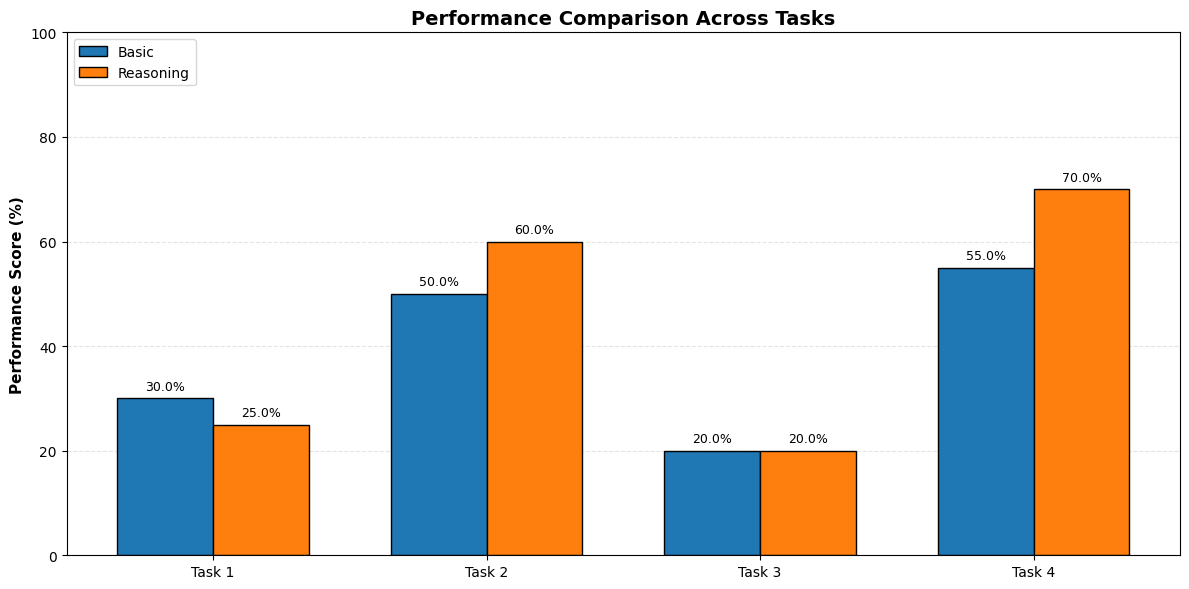

In [10]:
# ── importlib.reload forces Python to re-read reporting.py from disk,
# ── bypassing Jupyter's module cache. This ensures the latest version is used.
import importlib
import src.reporting
importlib.reload(src.reporting)
from src.reporting import plot_grouped_bar_chart

fig_grouped = plot_grouped_bar_chart(chart_df, save_path=FIGURES_DIR / "grouped_bar_chart.png")


## 9. Discussion

The results summarized in the table and visualized in the bar chart reveal clear trends in model performance across tasks of varying complexity.

For **Task 1 (Stable Matching Generation)**, both models achieve only **6/20 stable matchings (30%)**, despite often producing valid outputs. This highlights a key distinction between validity and stability: while models can generate well-formed matchings (high parsed/valid rates), ensuring global stability remains difficult. This aligns with Hosseini et al. (2025), who find that LLMs struggle to execute the full sequence of steps required by the Deferred Acceptance algorithm.

For **Task 2 (Instability Detection)**, the basic model achieves **50% accuracy** and the reasoning model achieves **60% accuracy**. While the reasoning model performs slightly better here, neither model is reliable. This suggests that even the larger model cannot consistently detect whether a matching is globally stable — a simple binary classification task that should, in theory, be easier than generation.

For **Task 3 (Instability Resolution)**, both models achieve only 20% stable resolutions. Despite being given an existing matching to fix (rather than generating from scratch), models still struggle to produce stable outcomes, suggesting difficulty in maintaining global consistency. The reasoning model shows no advantage.

For **Task 4 (Preference Reasoning)**, both models perform significantly better, with the basic model achieving **55% accuracy** and the reasoning model reaching **70%**. This indicates that local reasoning over preferences is substantially easier than constructing or repairing full matchings, as it does not require maintaining consistency across multiple agents. This mirrors the paper's finding that preference-level queries are within current LLM capability.

**Note:** The full four-task pipeline was restricted to the 5-agent IC dataset, as baseline Groq models showed limited performance even at the smallest scale. Given limited API usage and computational cost, harder datasets were evaluated separately using Gemini 2.5 Pro on Task 1 to assess scalability.

The extended evaluation using the Gemini model further supports these observations. While Gemini achieves strong performance on smaller instances (e.g., **100%** stable matchings on easy datasets), its performance degrades significantly on larger instances (high blocking pair counts in **50-agent** settings). This mirrors the pattern reported in Hosseini et al. (2025), where LLMs perform well on small-scale problems but struggle as combinatorial complexity increases.

Overall, the results suggest that LLMs are effective at local reasoning tasks, such as preference comparison, but face significant challenges in global algorithmic execution. Performance degrades as task complexity increases, supporting the view that current LLMs rely more on heuristic reasoning than on fully simulating structured algorithms.


## 10. Conclusion

This project evaluated the ability of LLMs to perform structured reasoning using stable matching tasks. While models often produced valid outputs, they struggled to ensure global stability, highlighting a gap between surface-level correctness and true algorithmic reasoning.

These results can be explained by how LLMs operate. Stable matching requires maintaining consistency across multiple interdependent decisions, similar to executing the Deferred Acceptance algorithm. However, LLMs do not explicitly simulate such step-by-step procedures; instead, they rely on pattern recognition and local reasoning. As a result, they can correctly interpret preferences but fail to enforce global constraints, leading to unstable matchings.

The variation in performance across tasks further supports this. Tasks like preference reasoning are easier because they involve local comparisons, whereas tasks like stable matching generation and resolution require tracking interactions across all agents, increasing the chance of error accumulation.

The extended evaluation with Gemini highlights another key factor: scalability. As the number of agents increases, the problem becomes combinatorially more complex, making it harder for models to maintain consistency. This aligns with findings in prior work, where LLM performance degrades on larger, more structured tasks.

## 11. Future Work

Future work can explore methods to better support structured reasoning in LLMs. One direction is the use of step-by-step or chain-of-thought prompting, which may help models follow multi-step procedures more reliably. Additionally, incorporating intermediate verification steps such as explicitly checking for blocking pairs could improve consistency in generated matchings.

Another direction is to integrate algorithmic guidance, where models are prompted or constrained to follow structured procedures similar to the Deferred Acceptance algorithm. This may reduce errors arising from purely heuristic reasoning.

Further evaluation on larger and more diverse datasets would also help better understand how performance scales with problem complexity. Finally, comparing a wider range of advanced models could provide deeper insights into the limits of LLM reasoning on combinatorial tasks.

## 12. References

[1] Hadi Hosseini, Samarth Khanna, Ronak Singh. "Matching Markets Meet LLMs: Algorithmic Reasoning with Ranked Preferences", arXiv:2506.04478, 2025. [[Link to Paper]](https://arxiv.org/pdf/2506.04478)
